In [1]:
import sys
import os

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

sys.path.append(os.getcwd())

from src.splits import create_lesion_splits
from src.dataset import HAM10000Dataset, get_train_transforms, get_eval_transforms, compute_class_weights, IMAGENET_MEAN, IMAGENET_STD, DX_TO_IDX, IDX_TO_DX
import pandas as pd
import numpy as np
import torch

In [2]:
df = pd.read_csv('./data/HAM10000_metadata.csv')
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


Split into Train, Test, and Validation Sets

In [3]:
train_df, test_df, val_df = create_lesion_splits(df, random_state=10, val_size=0.15, test_size=0.15, tolerance=0.03)

✓ No lesion_id overlap across train/val/test
  Train: 5228 lesions, Val: 1121 lesions, Test: 1121 lesions
✓ train split class proportions within 3% of full dataset (max deviation: 0.000)
✓ val split class proportions within 3% of full dataset (max deviation: 0.000)
✓ test split class proportions within 3% of full dataset (max deviation: 0.000)


In [6]:
train_df.to_csv('./data/splits/train.csv', index=False)
val_df.to_csv('./data/splits/val.csv', index=False)
test_df.to_csv('./data/splits/test.csv', index=False)

In [ ]:
image_dir = os.path.join(os.getcwd(), 'data', 'HAM10000_images')

Check that train transformations return the proper size, data type, and valid label

In [ ]:
train_dataset = HAM10000Dataset(train_df, image_dir, get_train_transforms())

img, label = train_dataset.__getitem__(4)
assert img.shape == (3, 224, 224), f"Unexpected shape: {img.shape}"
assert isinstance(label, (int, np.integer)), f"Expected int, got {type(label)}"
assert 0 <= label <= 6, f"Label out of range: {label}"

<bound method HAM10000Dataset.__len__ of <src.dataset.HAM10000Dataset object at 0x000001BDD6DF3C10>>


Check to ensure that eval transformations are deterministic

In [9]:
val_dataset = HAM10000Dataset(val_df, image_dir, get_eval_transforms())
img1, _ = val_dataset[0]
img2, _ = val_dataset[0]
assert torch.equal(img1, img2), "Eval transform is not deterministic!"

Check to ensure transformations are being applied to training data

In [10]:
img1, _ = train_dataset[0]
img2, _ = train_dataset[0]
assert not torch.equal(img1, img2), "Train transform doesn't appear to be augmenting!"

In [ ]:
def unnormalize(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """Reverse ImageNet normalization for display purposes."""
    tensor = tensor.clone()
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)  # reverse: (x * std) + mean
    return tensor.clamp(0, 1).permute(1, 2, 0).numpy()  # CHW -> HWC for matplotlib

Show one image for each class with training augmentations

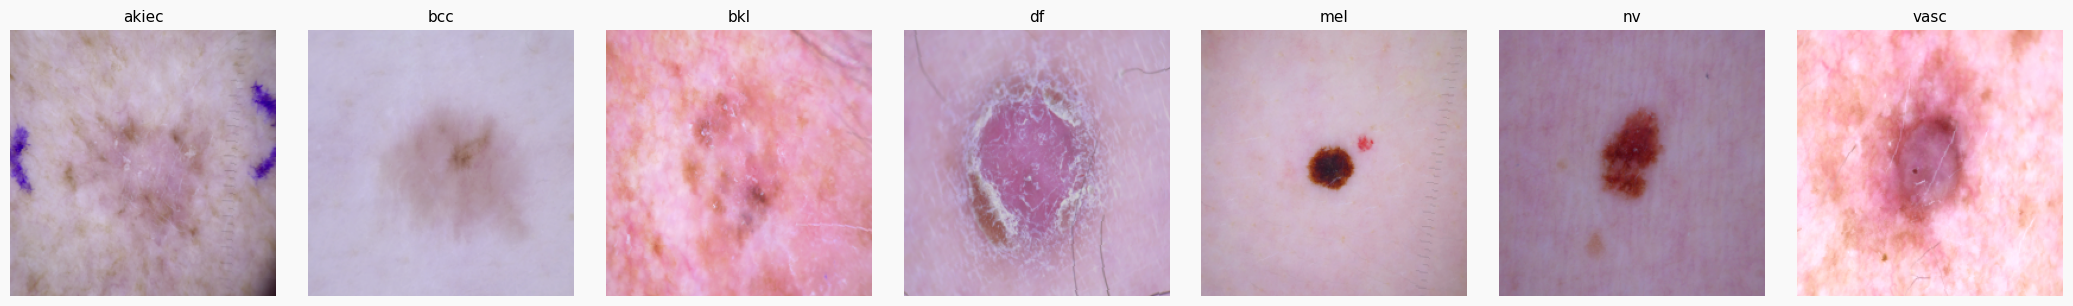

In [64]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 7, figsize=(21, 3))
fig.patch.set_facecolor('#F9F9F9')

for i, dx_class in enumerate(DX_TO_IDX.keys()):
    match_idx = train_df[train_df['dx'] == dx_class].index[0]
    pos = train_df.index.get_loc(match_idx)
    
    img_tensor, label = train_dataset[pos]
    axes[i].imshow(unnormalize(img_tensor))
    axes[i].set_title(dx_class, fontsize=11)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Show #n_augmentations different training augmentations of image at sample_idx

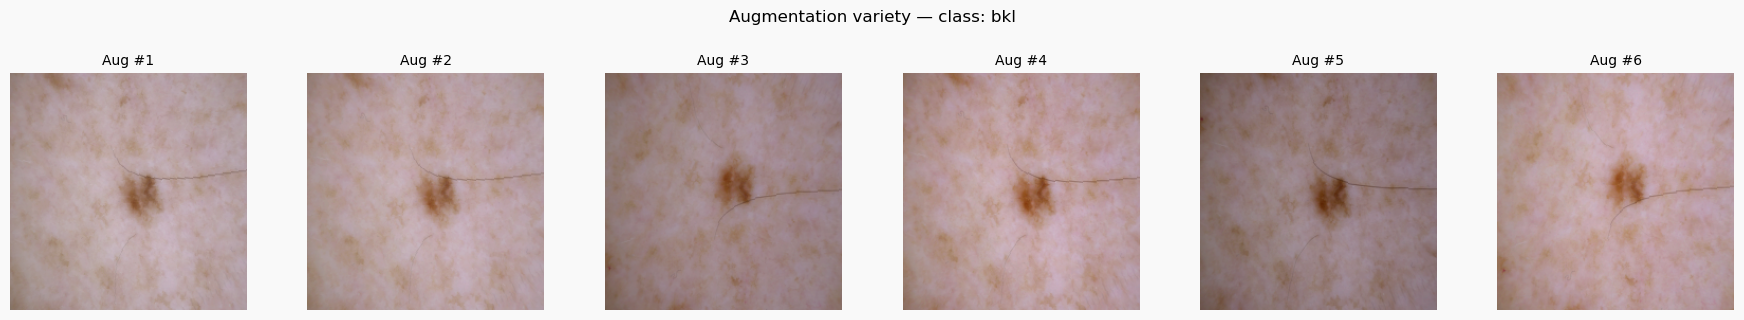

In [57]:
sample_idx = 29  # pick any index
n_augmentations = 6

fig, axes = plt.subplots(1, n_augmentations, figsize=(3 * n_augmentations, 3))
fig.patch.set_facecolor('#F9F9F9')

for i in range(n_augmentations):
    img_tensor, label = train_dataset[sample_idx]  # __getitem__ re-runs the random transform each call
    axes[i].imshow(unnormalize(img_tensor))
    axes[i].set_title(f"Aug #{i+1}", fontsize=10)
    axes[i].axis('off')

fig.suptitle(f"Augmentation variety — class: {IDX_TO_DX[label]}", y=1.05)
plt.tight_layout()
plt.show()

Calculate class weights

In [ ]:
weights = compute_class_weights(train_df)
print(weights)


tensor([ 4.5877,  2.7678,  1.3031, 12.5589,  1.2702,  0.2133, 10.2522])
